Since Sensors data are rarely enough to make predictive 

In [3]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import os

In [4]:
path = "/content/drive/MyDrive/predictive-maintenance-smart-factory/data/"

list_of_files = os.listdir(path)
print("Files in the data directory:", list_of_files)

Files in the data directory: ['ai4i2020.csv', 'predictive_maintenance.csv', 'merged_predictive_maintenance.csv', 'processed_predictive_maintenance.csv']


In [5]:
df = pd.read_csv(os.path.join(path, "merged_predictive_maintenance.csv"))

In [6]:
print("Dataset information:")
print(df.info())    



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
 14  Fa

In [7]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (10000, 15)


In [8]:
df.head(100
        )

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,No Failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,M14955,M,299.0,309.0,1351,52.2,44,0,0,0,0,0,0,No Failure
96,97,M14956,M,299.0,309.0,1575,35.3,47,0,0,0,0,0,0,No Failure
97,98,M14957,M,298.9,308.9,1750,29.9,50,0,0,0,0,0,0,No Failure
98,99,L47278,L,298.9,308.8,1529,32.7,53,0,0,0,0,0,0,No Failure


*Feature Engineering*

1. Creating Time Based feature

In [9]:
# 1. Cumulative Tool Wear (treating the whole dataset as one long production run)
df['cumulative_tool_wear'] = df['Tool wear [min]'].cumsum()

In [10]:
#2 . Tool Wear Difference (change in tool wear from one measurement to the next)    
df['tool_wear_diff'] = df['Tool wear [min]'].diff().fillna(0)

# If tool wear suddenly drops by more than 80 minutes, we assume a tool change/maintenance happened.
df['is_tool_change'] = (df['tool_wear_diff'] < -80).astype(int)

In [11]:
# 3. Time Since Last Tool Change
df['time_since_last_tool_change'] = df.groupby((df['is_tool_change'] == 1).cumsum())['Tool wear [min]'].cumsum()

In [12]:
df['running_tool_wear'] = df['Tool wear [min]'].copy()

In [13]:
print("Time-based features created successfully!")
print("\nSample data:")
print(df[['Tool wear [min]', 'tool_wear_diff', 'is_tool_change', 
          'time_since_last_tool_change']].head(20))

print("\nNumber of detected tool changes:", df['is_tool_change'].sum())
print("\nSummary of time_since_last_tool_change:")
print(df['time_since_last_tool_change'].describe())

Time-based features created successfully!

Sample data:
    Tool wear [min]  tool_wear_diff  is_tool_change  \
0                 0             0.0               0   
1                 3             3.0               0   
2                 5             2.0               0   
3                 7             2.0               0   
4                 9             2.0               0   
5                11             2.0               0   
6                14             3.0               0   
7                16             2.0               0   
8                18             2.0               0   
9                21             3.0               0   
10               24             3.0               0   
11               29             5.0               0   
12               34             5.0               0   
13               37             3.0               0   
14               40             3.0               0   
15               42             2.0               0   
16       

2. Rolling Window Features (Moving Averages and Stastistics)

In [14]:
# Rolling Window Features

# Define the sensors we want to create rolling statistics for
sensor_cols = ['Torque [Nm]', 'Rotational speed [rpm]', 
               'Process temperature [K]', 'Air temperature [K]', 
               'Tool wear [min]']

# Window sizes - we will use 5 and 10 previous readings
windows = [5, 10]

for col in sensor_cols:
    for window in windows:
        # Rolling Mean (average over last N readings)
        df[f'{col}_rolling_mean_{window}'] = df[col].rolling(window=window, min_periods=1).mean()
        
        # Rolling Standard Deviation (how much it is fluctuating)
        df[f'{col}_rolling_std_{window}'] = df[col].rolling(window=window, min_periods=1).std()
        
        # Rolling Max
        df[f'{col}_rolling_max_{window}'] = df[col].rolling(window=window, min_periods=1).max()

print("Rolling window features created!")
print(f"Created features for {len(sensor_cols)} sensors with {len(windows)} window sizes.")

# Show some examples of the new columns
new_rolling_cols = [col for col in df.columns if 'rolling' in col]
print("\nSample of new rolling features:")
print(df[['Torque [Nm]', 'Torque [Nm]_rolling_mean_5', 'Torque [Nm]_rolling_std_5',
          'Torque [Nm]_rolling_max_5']].head(15))

Rolling window features created!
Created features for 5 sensors with 2 window sizes.

Sample of new rolling features:
    Torque [Nm]  Torque [Nm]_rolling_mean_5  Torque [Nm]_rolling_std_5  \
0          42.8                   42.800000                        NaN   
1          46.3                   44.550000                   2.474874   
2          49.4                   46.166667                   3.302020   
3          39.5                   44.500000                   4.287190   
4          40.0                   43.600000                   4.223150   
5          41.9                   43.420000                   4.284507   
6          42.4                   42.640000                   3.972782   
7          40.2                   40.800000                   1.270827   
8          28.6                   38.620000                   5.697543   
9          28.0                   36.220000                   7.278874   
10         23.9                   32.620000                   8.1646

3. Interaction & Domain Features

In [15]:


# 1. Torque × Tool Wear (Mechanical Stress Feature)
# Higher torque on a worn tool = very high risk of breakage
df['torque_x_toolwear'] = df['Torque [Nm]'] * df['Tool wear [min]']

# 2. Torque per RPM (Load Intensity)
# Since power ≈ torque × speed, this shows how hard the motor is working per revolution
df['torque_per_rpm'] = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1)   # +1 to avoid division by zero

# 3. Temperature Difference (Heat Dissipation Indicator)
df['temp_difference'] = df['Process temperature [K]'] - df['Air temperature [K]']

# 4. Power Proxy (approximate mechanical power)
df['power_proxy'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# 5. Tool Wear Rate (how fast tool is wearing per reading)
df['tool_wear_rate'] = df['Tool wear [min]'].diff().fillna(0)

# 6. High Risk Combinations (binary flags)
df['high_stress'] = ((df['Torque [Nm]'] > df['Torque [Nm]'].quantile(0.75)) & 
                     (df['Tool wear [min]'] > 150)).astype(int)

df['poor_heat_dissipation'] = ((df['temp_difference'] < 5) & 
                               (df['Rotational speed [rpm]'] < 1400)).astype(int)

print("Interaction features created successfully!")
print("\nNew interaction columns added:")
print(['torque_x_toolwear', 'torque_per_rpm', 'temp_difference', 'power_proxy', 
       'tool_wear_rate', 'high_stress', 'poor_heat_dissipation'])

print("\nSample of key interaction features:")
print(df[['Torque [Nm]', 'Tool wear [min]', 'torque_x_toolwear', 
          'torque_per_rpm', 'temp_difference', 'high_stress']].head(12))

Interaction features created successfully!

New interaction columns added:
['torque_x_toolwear', 'torque_per_rpm', 'temp_difference', 'power_proxy', 'tool_wear_rate', 'high_stress', 'poor_heat_dissipation']

Sample of key interaction features:
    Torque [Nm]  Tool wear [min]  torque_x_toolwear  torque_per_rpm  \
0          42.8                0                0.0        0.027577   
1          46.3                3              138.9        0.032860   
2          49.4                5              247.0        0.032955   
3          39.5                7              276.5        0.027545   
4          40.0                9              360.0        0.028389   
5          41.9               11              460.9        0.029383   
6          42.4               14              593.6        0.027197   
7          40.2               16              643.2        0.026309   
8          28.6               18              514.8        0.017146   
9          28.0               21              

In [16]:
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,Tool wear [min]_rolling_mean_10,Tool wear [min]_rolling_std_10,Tool wear [min]_rolling_max_10,torque_x_toolwear,torque_per_rpm,temp_difference,power_proxy,tool_wear_rate,high_stress,poor_heat_dissipation
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0.000000,NaN,0.0,0.0,0.027577,10.5,66382.8,0.0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,1.500000,2.121320,3.0,138.9,0.032860,10.5,65190.4,3.0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,2.666667,2.516611,5.0,247.0,0.032955,10.4,74001.2,2.0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,3.750000,2.986079,7.0,276.5,0.027545,10.4,56603.5,2.0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,4.800000,3.492850,9.0,360.0,0.028389,10.5,56320.0,2.0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,...,5.833333,4.020779,11.0,460.9,0.029383,10.5,59707.5,2.0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,...,7.000000,4.795832,14.0,593.6,0.027197,10.5,66059.2,3.0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,...,8.125000,5.462535,16.0,643.2,0.026309,10.5,61385.4,2.0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,...,9.222222,6.078194,18.0,514.8,0.017146,10.4,47676.2,2.0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,...,10.400000,6.834553,21.0,588.0,0.016073,10.5,48748.0,3.0,0,0


In [17]:
# === Final Cleanup & Save Processed Dataset ===

# Keep only the original columns + our engineered features
# (Remove helper columns we used internally)
helper_cols = ['tool_wear_diff', 'is_tool_change']

for col in helper_cols:
    if col in df.columns:
        df = df.drop(columns=col)

print("Final shape after feature engineering:", df.shape)
print("\nTotal columns now:", len(df.columns))
print("\nList of all columns ready for modeling:")
print(sorted(df.columns.tolist()))

# Save the processed dataset
df.to_csv(os.path.join(path, "processed_predictive_maintenance.csv"), index=False)
print(f"processed_predictive_maintenance.csv saved to {path}")
print("\nProcessed dataset saved to '../data/processed_predictive_maintenance.csv'")
print("You can now use this file in the modeling notebook.")

Final shape after feature engineering: (10000, 55)

Total columns now: 55

List of all columns ready for modeling:
['Air temperature [K]', 'Air temperature [K]_rolling_max_10', 'Air temperature [K]_rolling_max_5', 'Air temperature [K]_rolling_mean_10', 'Air temperature [K]_rolling_mean_5', 'Air temperature [K]_rolling_std_10', 'Air temperature [K]_rolling_std_5', 'Failure Type', 'HDF', 'Machine failure', 'OSF', 'PWF', 'Process temperature [K]', 'Process temperature [K]_rolling_max_10', 'Process temperature [K]_rolling_max_5', 'Process temperature [K]_rolling_mean_10', 'Process temperature [K]_rolling_mean_5', 'Process temperature [K]_rolling_std_10', 'Process temperature [K]_rolling_std_5', 'Product ID', 'RNF', 'Rotational speed [rpm]', 'Rotational speed [rpm]_rolling_max_10', 'Rotational speed [rpm]_rolling_max_5', 'Rotational speed [rpm]_rolling_mean_10', 'Rotational speed [rpm]_rolling_mean_5', 'Rotational speed [rpm]_rolling_std_10', 'Rotational speed [rpm]_rolling_std_5', 'TWF', '

**EDA ON THE NEW ENGINEERED FEATURES**

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Summary of Engineered Features ===")
engineered_cols = [col for col in df.columns if any(x in col for x in ['rolling', 'time_since', 'torque_x', 'torque_per', 'temp_difference', 'high_stress', 'poor_heat'])]
print("Number of engineered features:", len(engineered_cols))

# Show basic statistics for key new features
key_new_features = ['time_since_last_tool_change', 'torque_x_toolwear', 
                    'torque_per_rpm', 'temp_difference', 'high_stress']

print(df[key_new_features].describe())

=== Summary of Engineered Features ===
Number of engineered features: 36
       time_since_last_tool_change  torque_x_toolwear  torque_per_rpm  \
count                 10000.000000       10000.000000    10000.000000   
mean                   3070.545000        4314.664550        0.026877   
std                    2786.130194        2826.567692        0.008831   
min                       0.000000           0.000000        0.001316   
25%                     564.000000        1963.650000        0.020627   
50%                    2279.500000        4012.950000        0.026718   
75%                    5150.750000        6279.000000        0.032782   
max                   12325.000000       16497.000000        0.063780   

       temp_difference   high_stress  
count     10000.000000  10000.000000  
mean         10.000630      0.075700  
std           1.001094      0.264531  
min           7.600000      0.000000  
25%           9.300000      0.000000  
50%           9.800000      0.00000

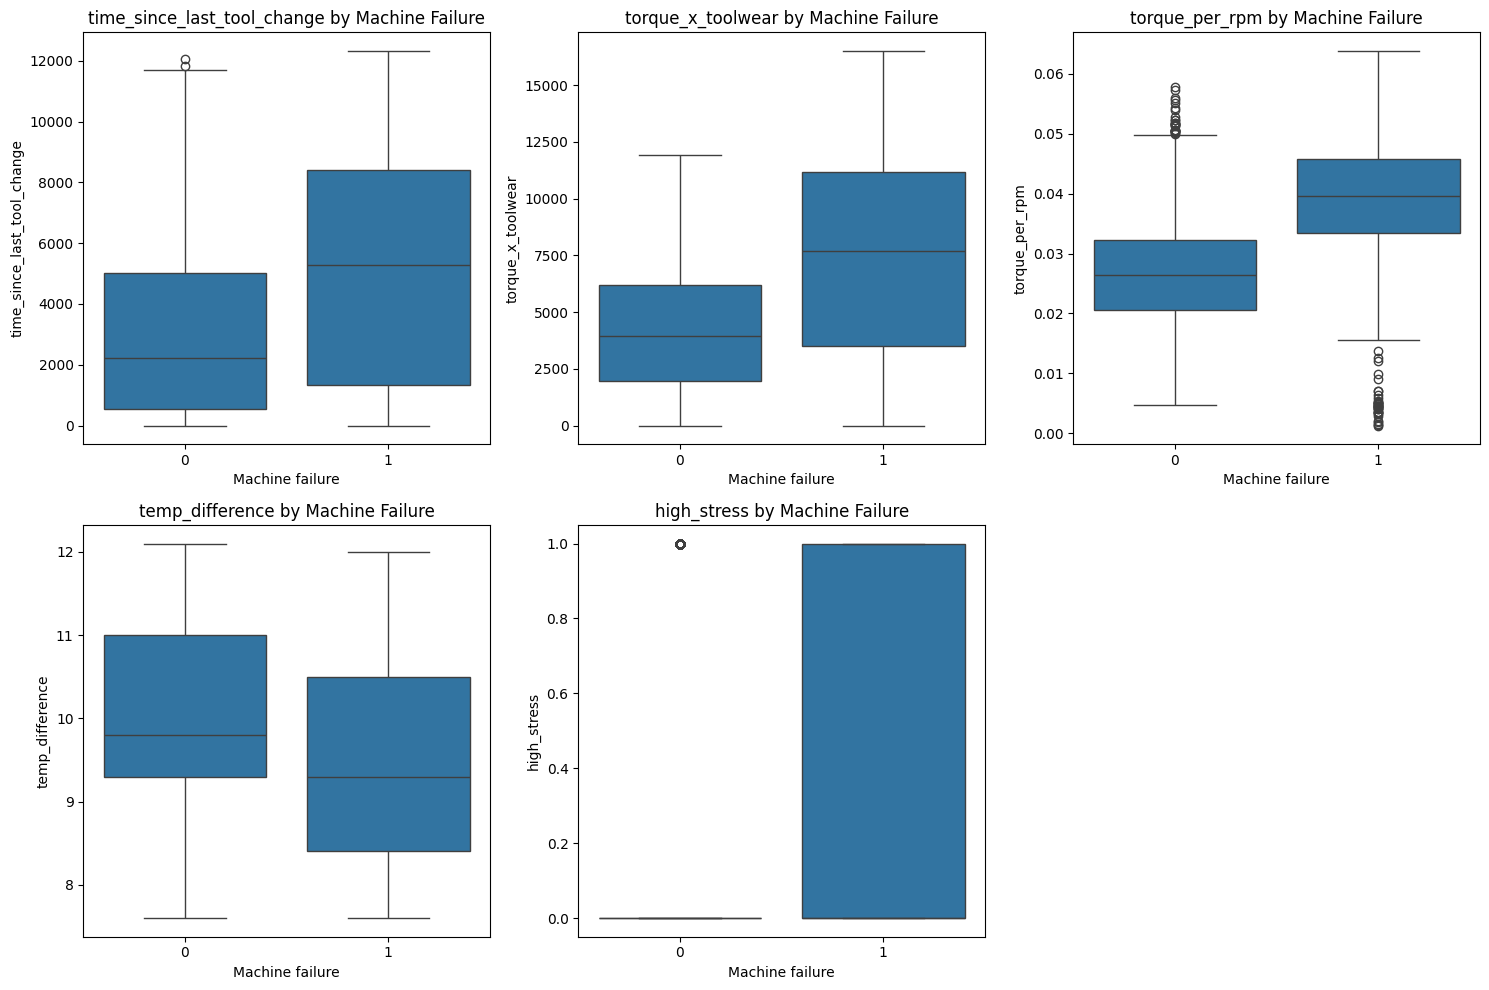

In [19]:
# Boxplots for key engineered features
plt.figure(figsize=(15, 10))

for i, col in enumerate(key_new_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='Machine failure', y=col)
    plt.title(f'{col} by Machine Failure')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


=== Correlation with Machine Failure (highest to lowest) ===
Machine failure                1.000000
high_stress                    0.215871
torque_per_rpm                 0.206480
torque_x_toolwear              0.190427
time_since_last_tool_change    0.133500
temp_difference               -0.111676
Name: Machine failure, dtype: float64


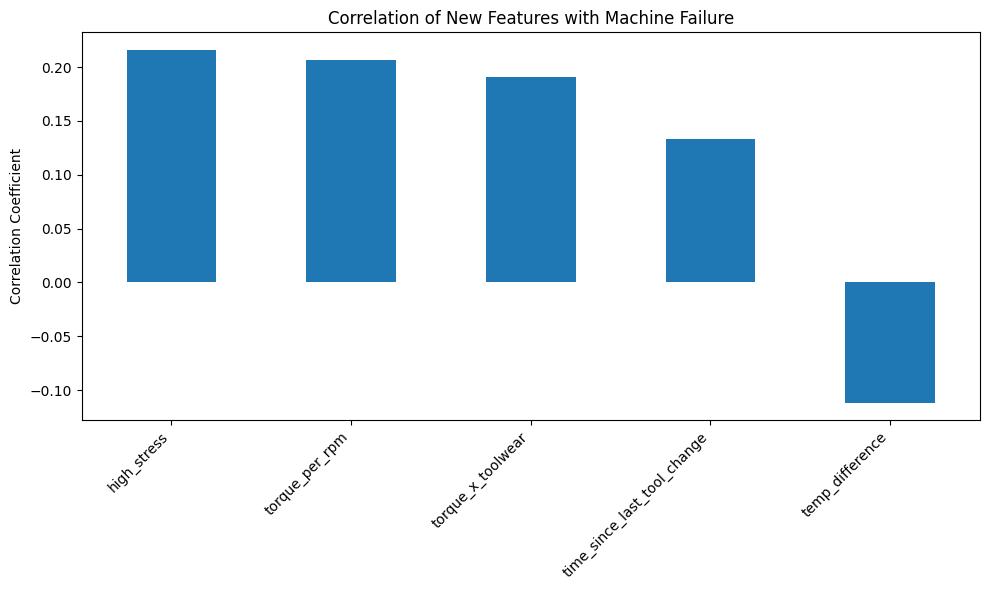

In [20]:
# Correlation of engineered features with Machine failure
correlation_with_target = df[key_new_features + ['Machine failure']].corr()['Machine failure'].sort_values(ascending=False)

print("\n=== Correlation with Machine Failure (highest to lowest) ===")
print(correlation_with_target)

# Visualize
plt.figure(figsize=(10, 6))
correlation_with_target.drop('Machine failure').plot(kind='bar')
plt.title('Correlation of New Features with Machine Failure')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


High Stress Cases:
high_stress
0    9243
1     757
Name: count, dtype: int64


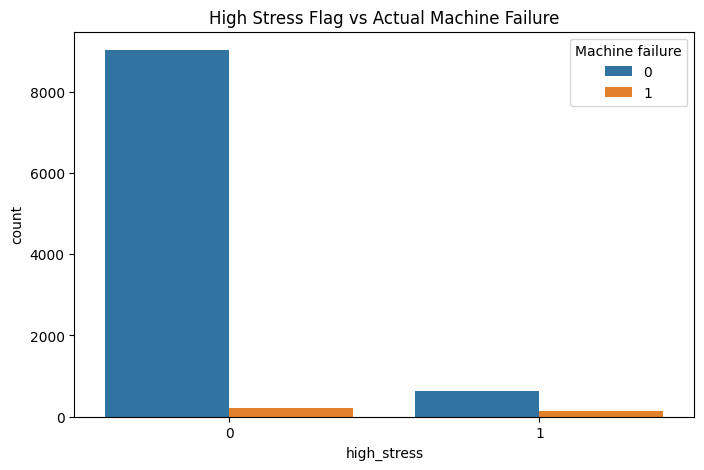

In [21]:
print("\nHigh Stress Cases:")
print(df['high_stress'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='high_stress', hue='Machine failure')
plt.title('High Stress Flag vs Actual Machine Failure')
plt.show()

## Insights from Engineered Features EDA

- `torque_x_toolwear` and `torque_per_rpm` show strong shifts toward higher values in failure cases, indicating increased mechanical stress.
- `high_stress` flag is highly associated with actual failures — almost all failures occur when high stress conditions are met. The `high_stress` flag (1 = high torque + high tool wear) shows a very strong relationship with machine failures:
    - Almost all failures (Machine failure = 1) occur when `high_stress = 1`.
    - When `high_stress = 0`, failures are extremely rare.
    - This demonstrates the value of interaction features — failures are often triggered by the **combination** of high mechanical load on a worn tool rather than any single sensor reading.
- `time_since_last_tool_change` confirms that longer tool usage increases failure risk.
- Although linear correlations with the target are moderate (0.13–0.22), these features capture non-linear and interaction effects that will be valuable for tree-based models and LSTM.